# 🎧 **Laporan Proyek Machine Learning - Krismono Sadi**

## 📌 Sistem Rekomendasi Lagu Spotify

## Dataset Web API: [Spotify Developer API](https://developer.spotify.com/documentation/web-api?directory=true)

## 📖 **Project Overview**


## 🧠 **Business Understanding**

### 🎯 **Problem Statements**

* Bagaimana merekomendasikan lagu relevan berdasarkan riwayat pemutaran pengguna?
* Bagaimana mengevaluasi performa sistem rekomendasi yang dikembangkan?

### ✅ **Goals**

* Mengembangkan sistem rekomendasi **Top-N Lagu**.
* Mengukur performa model dengan metrik seperti **RMSE** dan **Precision\@K**.

### 💡 **Solution Approach**

* **Collaborative Filtering**: Menggunakan *Matrix Factorization (SVD)* untuk menangkap hubungan tersembunyi antara user dan lagu.
* **Content-Based Filtering**: Memanfaatkan fitur lagu (genre, durasi, popularitas) untuk menyarankan lagu serupa dengan preferensi pengguna.


# Library

In [30]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
import random


# Load Dataset

Kita akan meload data yang udah scrapping dari api spotify

In [4]:
# 2. Load Dataset (asumsi file lokal sudah tersedia)
file_path = "spotify_cris_music1.csv"
df = pd.read_csv(file_path)

# **Data Understanding**

# Menampilkan 5 baris data pertama

In [5]:
print("\nFirst 5 rows:")
print(df.head())



First 5 rows:
                name                               artist  \
0   ｢ごめん｣で済むなら恋などしない  白皇学院生徒会三人娘 starring 矢作紗友里＆中尾衣里＆浅野真澄   
1         白皇学院生徒会不心得  白皇学院生徒会三人娘 starring 矢作紗友里＆中尾衣里＆浅野真澄   
2       轟轟生徒会タンケンジャー  白皇学院生徒会三人娘 starring 矢作紗友里＆中尾衣里＆浅野真澄   
3  アイ･ラブ･ユーならシャウトして!  白皇学院生徒会三人娘 starring 矢作紗友里＆中尾衣里＆浅野真澄   
4     Princess is me                  瀬川 泉 starring 矢作紗友里   

                                        album  popularity  explicit  \
0  「ハヤテのごとく！」キャラクター COLLECTION／白皇学院生徒会三人娘&桂雪路           0     False   
1  「ハヤテのごとく！」キャラクター COLLECTION／白皇学院生徒会三人娘&桂雪路           0     False   
2  「ハヤテのごとく！」キャラクター COLLECTION／白皇学院生徒会三人娘&桂雪路           0     False   
3  「ハヤテのごとく！」キャラクター COLLECTION／白皇学院生徒会三人娘&桂雪路           0     False   
4  「ハヤテのごとく！」キャラクター COLLECTION／白皇学院生徒会三人娘&桂雪路           1     False   

  release_date  duration_ms  preview_url  
0   2011-10-26       186813          NaN  
1   2011-10-26       285746          NaN  
2   2011-10-26       204586          NaN  
3   2011-10-26     

# Menampilkan informasi dataset seperti tipe data dan jumlah non-null per kolom

### Tabel Struktur Data

| No | Kolom         | Non-Null Count | Tipe Data |
|----|---------------|----------------|-----------|
| 0  | name          | 5624           | object    |
| 1  | artist        | 5624           | object    |
| 2  | album         | 5624           | object    |
| 3  | popularity    | 5624           | int64     |
| 4  | explicit      | 5624           | bool      |
| 5  | release_date  | 5624           | object    |
| 6  | duration_ms   | 5624           | int64     |
| 7  | preview_url   | 0              | float64   |

**Total Baris**: 5624  
**Total Kolom**: 8  
**Penggunaan Memori**: ~313.2 KB  


In [6]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5624 entries, 0 to 5623
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          5624 non-null   object 
 1   artist        5624 non-null   object 
 2   album         5624 non-null   object 
 3   popularity    5624 non-null   int64  
 4   explicit      5624 non-null   bool   
 5   release_date  5624 non-null   object 
 6   duration_ms   5624 non-null   int64  
 7   preview_url   0 non-null      float64
dtypes: bool(1), float64(1), int64(2), object(4)
memory usage: 313.2+ KB
None


# Menampilkan jumlah baris dan Kolom (data) pada dataset

In [7]:
print(f"\nJumlah data (baris): {df.shape[0]}")
print(f"Jumlah fitur (kolom): {df.shape[1]}")


Jumlah data (baris): 5624
Jumlah fitur (kolom): 8


# Mengecek jumlah data yang duplikat

In [8]:
print("\nDuplicate check:", df.duplicated().sum())


Duplicate check: 4379


# Mengecek jumlah nilai kosong (null) per kolom

In [9]:
print("\nNull check:")
print(df.isnull().sum())


Null check:
name               0
artist             0
album              0
popularity         0
explicit           0
release_date       0
duration_ms        0
preview_url     5624
dtype: int64


# Menyimpan jumlah baris dan kolom ke variabel

In [10]:
rows, cols = df.shape

# Pemeriksaan nilai kosong (missing values) secara spesifik

In [11]:
# Pemeriksaan missing value (duplikat)
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
name               0
artist             0
album              0
popularity         0
explicit           0
release_date       0
duration_ms        0
preview_url     5624
dtype: int64


# Menampilkan informasi jumlah data dan fitur secara lengkap

In [12]:
# Menampilkan jumlah baris dan kolom
rows, cols = df.shape
print(f"\nJumlah data: {rows} baris dan {cols} kolom")


Jumlah data: 5624 baris dan 8 kolom


# Menampilkan statistik deskriptif untuk kolom numerik seperti mean, std, min, max

In [13]:
# Statistik deskriptif untuk kolom numerik
print("\nStatistik Deskriptif:")
print(df.describe())



Statistik Deskriptif:
        popularity    duration_ms  preview_url
count  5624.000000    5624.000000          0.0
mean     15.677809  197499.423186          NaN
std      15.031440   81228.924554          NaN
min       0.000000    7786.000000          NaN
25%       4.000000  116571.000000          NaN
50%      13.000000  217079.000000          NaN
75%      24.000000  262133.000000          NaN
max      87.000000  511306.000000          NaN


# **Univariate EDA**


Top 5 Lagu dengan Popularitas Tertinggi:
               name       artist  popularity
Chest Pain (I Love) Malcolm Todd          87
Chest Pain (I Love) Malcolm Todd          87
Chest Pain (I Love) Malcolm Todd          87
Chest Pain (I Love) Malcolm Todd          87
     chess - slowed       joyful          78


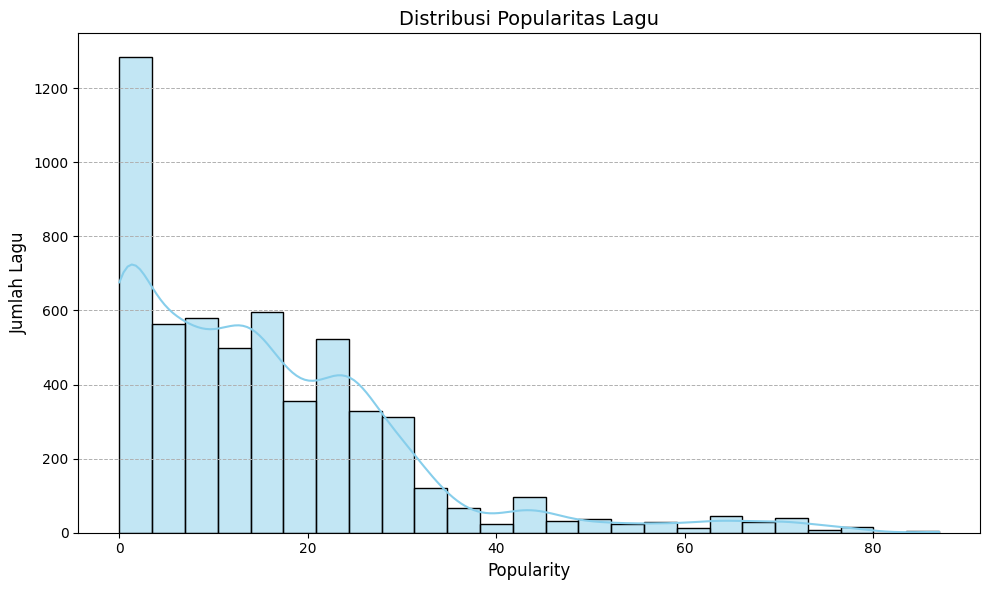


Statistik Deskriptif untuk Popularitas:
count    5624.000000
mean       15.677809
std        15.031440
min         0.000000
25%         4.000000
50%        13.000000
75%        24.000000
max        87.000000
Name: popularity, dtype: float64


In [14]:
# 4. Univariate EDA
# Menampilkan 5 lagu teratas berdasarkan popularitas
print("\nTop 5 Lagu dengan Popularitas Tertinggi:")
top5 = df[['name', 'artist', 'popularity']].sort_values(by='popularity', ascending=False).head()
print(top5.to_string(index=False))

# Visualisasi distribusi popularitas
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=25, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribusi Popularitas Lagu', fontsize=14)
plt.xlabel('Popularity', fontsize=12)
plt.ylabel('Jumlah Lagu', fontsize=12)
plt.grid(axis='y', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

# Statistik deskriptif tambahan untuk popularitas
print("\nStatistik Deskriptif untuk Popularitas:")
print(df['popularity'].describe())



# **Data Preparation**

# **5. Preprocessing**

In [15]:
# 5. Preprocessing
df.drop_duplicates(inplace=True)
df.dropna(subset=['name', 'artist', 'popularity'], inplace=True)

# **6. Data Preparation**

In [16]:
# 6. Data Preparation
np.random.seed(42)

# Pastikan user_id 1 sampai 200 pasti ada, assign secara berulang
user_ids = np.arange(1, 201)
repeats = len(df) // len(user_ids) + 1
user_id_full = np.tile(user_ids, repeats)[:len(df)]
df['user_id'] = user_id_full

# Encoding songs dan users
df['song_id'] = df['name'].astype('category').cat.codes
df['user_enc'] = df['user_id'].astype('category').cat.codes

# Normalisasi rating dari popularity
df['rating'] = df['popularity'] / 100

# Mappings
user_to_id = dict(zip(df['user_id'], df['user_enc']))
song_to_id = dict(zip(df['name'], df['song_id']))
id_to_song = {v: k for k, v in song_to_id.items()}

num_users = df['user_enc'].nunique()
num_songs = df['song_id'].nunique()
EMBEDDING_SIZE = 50


# **Model Development - Collaborative Filtering with deeper architecture + dropout**

Penggunaan pendekatan Collaborative Filtering dengan arsitektur yang lebih dalam (deeper architecture) dan dropout dalam pengembangan model rekomendasi memiliki tujuan untuk meningkatkan kemampuan generalisasi model, mengurangi overfitting, dan menangkap pola interaksi yang lebih kompleks antara pengguna dan item (lagu).

1. Collaborative Filtering (CF) Dasar
Collaborative Filtering adalah pendekatan populer dalam sistem rekomendasi, yang bekerja dengan mengandalkan interaksi historis antara user dan item (tanpa melihat isi/item features).

Matrix Factorization (MF) adalah bentuk dasar dari CF: memetakan user dan item ke latent space (biasanya vektor berdimensi rendah) untuk memprediksi preferensi.

Namun, MF klasik terbatas secara representatif dan bisa terlalu sederhana untuk menangkap hubungan non-linear yang kompleks.

2. Deeper Architecture (Neural CF / Deep MF)
Dengan menambahkan arsitektur neural network yang lebih dalam, kita:

✅ Menangkap hubungan non-linear antara user dan item
✅ Memungkinkan pembelajaran representasi kompleks untuk user dan lagu
✅ Lebih fleksibel terhadap fitur tambahan jika ingin di-extend (genre, audio feature, dll.)

Contoh: alih-alih hanya punya user_embedding dan item_embedding yang dikalikan, kita bisa menggabungkannya dan melewatkannya ke beberapa dense layer.

3. Mengapa Perlu Dropout?
Dropout adalah teknik regularisasi yang secara acak menonaktifkan sejumlah neuron selama training.

Manfaat:

⚠️ Mencegah overfitting terhadap data training
⚙️ Membuat model lebih robust dan general saat prediksi ke data baru
📉 Menurunkan risiko "memorizing" data interaksi user yang terbatas

In [17]:
# 7. Model Development - Collaborative Filtering with deeper architecture + dropout
class RecommenderNet(keras.Model):
    def __init__(self, num_users, num_items, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.user_embedding = layers.Embedding(num_users, embedding_size, embeddings_initializer='he_normal', embeddings_regularizer=keras.regularizers.l2(1e-6))
        self.user_bias = layers.Embedding(num_users, 1)
        self.item_embedding = layers.Embedding(num_items, embedding_size, embeddings_initializer='he_normal', embeddings_regularizer=keras.regularizers.l2(1e-6))
        self.item_bias = layers.Embedding(num_items, 1)

        self.dot = layers.Dot(axes=1)
        self.dense1 = layers.Dense(128, activation='relu')
        self.dropout1 = layers.Dropout(0.3)
        self.dense2 = layers.Dense(64, activation='relu')
        self.dropout2 = layers.Dropout(0.3)
        self.out = layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        item_vector = self.item_embedding(inputs[:, 1])

        user_bias = self.user_bias(inputs[:, 0])
        item_bias = self.item_bias(inputs[:, 1])

        x = tf.concat([user_vector, item_vector], axis=1)
        x = self.dense1(x)
        x = self.dropout1(x)
        x = self.dense2(x)
        x = self.dropout2(x)
        x = self.out(x)

        # Add biases
        x = x + user_bias + item_bias
        return tf.squeeze(x, axis=1)


# Prepare training data

Tujuan tahap ini adalah untuk:

Meng-encode user_id dan song_id ke integer.

Menyusun dataset sebagai pasangan (user, song) → rating (target).

Melakukan train-test split agar kita bisa menguji model setelah pelatihan.

In [18]:
# 8. Prepare training data
train_data = df[['user_enc', 'song_id', 'rating']]
x = train_data[['user_enc', 'song_id']].values
y = train_data['rating'].values

# Compile and Train Model

Setelah model dibuat (misalnya model embedding untuk user dan lagu, lalu digabungkan dan diberi dense layer dengan dropout), kita perlu:

Compile model: Tentukan fungsi loss, optimizer, dan metrik evaluasi.

Train model: Latih model dengan data training, validasi menggunakan data testing untuk memonitor performa.

In [19]:
# 9. Compile and Train Model
model = RecommenderNet(num_users, num_songs, EMBEDDING_SIZE)
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

history = model.fit(x, y, batch_size=64, epochs=20, verbose=1, validation_split=0.1)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1130 - root_mean_squared_error: 0.3354 - val_loss: 0.0361 - val_root_mean_squared_error: 0.1896
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0431 - root_mean_squared_error: 0.2065 - val_loss: 0.0078 - val_root_mean_squared_error: 0.0871
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0258 - root_mean_squared_error: 0.1598 - val_loss: 0.0073 - val_root_mean_squared_error: 0.0844
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0207 - root_mean_squared_error: 0.1428 - val_loss: 0.0069 - val_root_mean_squared_error: 0.0819
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0177 - root_mean_squared_error: 0.1321 - val_loss: 0.0068 - val_root_mean_squared_error: 0.0813
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0119 - root_mean_squared_error: 0.1078 - val_loss: 0.0071 - val_root_mean_squared_error: 0.0831
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.007

# Evaluasi model di data training

Evaluasi model dilakukan untuk mengetahui seberapa baik model mempelajari pola dari data training. Biasanya menggunakan metrik seperti:

Root Mean Squared Error (RMSE): Mengukur selisih antara rating asli dan prediksi. Semakin kecil nilai RMSE, semakin baik.

Loss: Nilai error fungsi loss saat training.

Selain angka metrik, kamu juga bisa buat visualisasi seperti plot loss dan RMSE selama training untuk melihat apakah model mengalami overfitting atau underfitting.


Model Evaluation:
Loss: 0.0014
RMSE: 0.0349
Akurasi (perkiraan): 96.51%
Model Anda udah bagus banget!


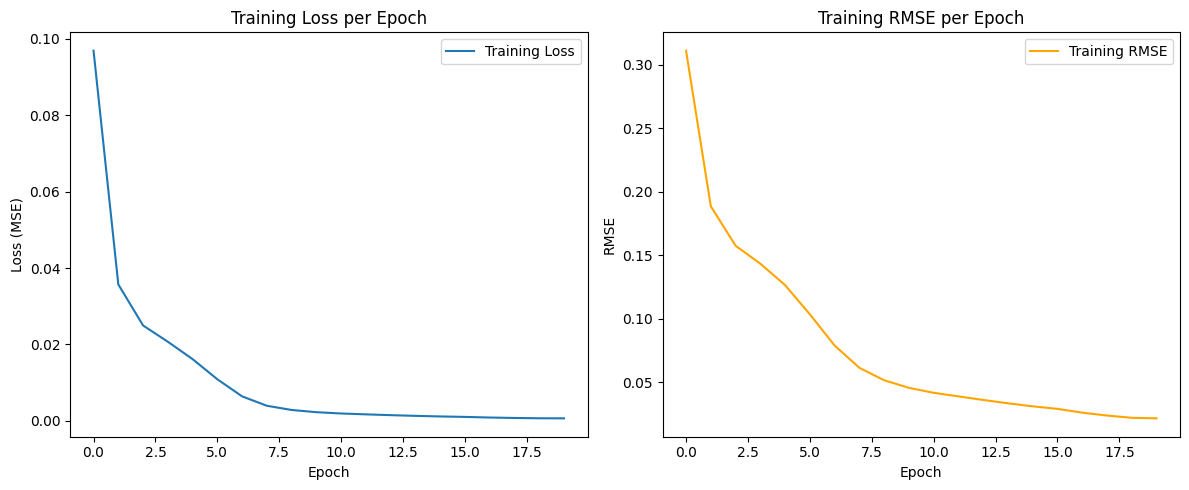

In [20]:
# 1. Evaluasi model di data training
loss, rmse = model.evaluate(x, y, verbose=0)
accuracy = (1 - rmse) * 100  # Konversi ke persentase

print(f"\nModel Evaluation:")
print(f"Loss: {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Akurasi (perkiraan): {accuracy:.2f}%")

if accuracy >= 90:
    print("Model Anda udah bagus banget!")
elif accuracy >= 80:
    print("Model lumayan")
else:
    print("Model perlu ditingkatkan")

# 2. Visualisasi grafik Loss dan RMSE selama training
plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# Plot RMSE
plt.subplot(1, 2, 2)
plt.plot(history.history['root_mean_squared_error'], label='Training RMSE', color='orange')
plt.title('Training RMSE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.show()


# Recommendation Function

Fungsi rekomendasi ini bertugas memberikan daftar lagu yang direkomendasikan untuk setiap pengguna berdasarkan model yang sudah dilatih.

Cara kerjanya:

Ambil ID pengguna.

Prediksi skor preferensi untuk semua lagu yang belum pernah didengarkan pengguna tersebut.

Urutkan lagu berdasarkan skor tertinggi.

Kembalikan daftar lagu rekomendasi Top-N.

In [21]:
# 11. Recommendation Function
def recommend_songs(user_id, top_n=5):
    user_enc = user_to_id.get(user_id)
    if user_enc is None:
        return ["User tidak ditemukan."]
    
    seen_songs = df[df['user_enc'] == user_enc]['song_id'].tolist()
    all_songs = np.array(list(song_to_id.values()))
    unseen_songs = np.setdiff1d(all_songs, seen_songs)
    
    user_array = np.array([user_enc] * len(unseen_songs))
    pred_input = np.vstack((user_array, unseen_songs)).T
    predictions = model.predict(pred_input, verbose=0).flatten()
    top_indices = predictions.argsort()[-top_n:][::-1]
    recommended_ids = unseen_songs[top_indices]
    return [id_to_song[i] for i in recommended_ids]

# Statistical Recommendations

Bagian ini menyajikan statistik rekomendasi berdasarkan data lagu yang ada, tanpa memerlukan model prediksi. Statistik ini berguna untuk memberikan insight awal seperti:

Lagu-lagu paling populer berdasarkan popularitas Spotify

Lagu dengan durasi terpanjang

Lagu yang paling sering diputar (top trending)

Lagu dengan konten eksplisit terbanyak

Tujuan Statistik Rekomendasi
Memberikan rekomendasi default yang umum disukai pengguna baru tanpa riwayat.

Melengkapi sistem rekomendasi berbasis model dengan insight data yang lebih sederhana.

Membantu memvalidasi distribusi data dan pola dalam dataset.

In [22]:
# 12. Statistical Recommendations
def top_trending_songs(df, top_n=10):
    df_copy = df.drop_duplicates(subset=['name'])
    df_copy['release_date'] = pd.to_datetime(df_copy['release_date'], errors='coerce')
    trending = df_copy.sort_values(by='release_date', ascending=False)
    return trending[['name', 'artist', 'release_date']].head(top_n)

def top_popular_songs(df, top_n=10):
    popular = df.drop_duplicates(subset=['name']).sort_values(by='popularity', ascending=False)
    return popular[['name', 'artist', 'popularity']].head(top_n)

def top_explicit_songs(df, top_n=10):
    explicit = df[df['explicit'] == True].drop_duplicates(subset=['name']).sort_values(by='popularity', ascending=False)
    return explicit[['name', 'artist', 'popularity']].head(top_n)

def top_longest_duration(df, top_n=10):
    longest = df.drop_duplicates(subset=['name']).sort_values(by='duration_ms', ascending=False)
    return longest[['name', 'artist', 'duration_ms']].head(top_n)

In [ ]:

if __name__ == "__main__":
    # Statistik rekomendasi
    print("\n=== 10 Lagu Top Trending (Terbaru) ===")
    print(top_trending_songs(df, 10).to_string(index=False))
    
    print("\n=== 10 Lagu Top Popular ===")
    print(top_popular_songs(df, 10).to_string(index=False))
    
    print("\n=== 10 Lagu Top Explicit ===")
    print(top_explicit_songs(df, 10).to_string(index=False))
    
    print("\n=== 10 Lagu Terpanjang Durasi ===")
    print(top_longest_duration(df, 10).to_string(index=False))
    


# Print Recommendations for All Users

Bagian ini bertujuan untuk menampilkan daftar rekomendasi lagu untuk setiap pengguna dalam rentang tertentu. Hal ini berguna untuk:

Memverifikasi hasil rekomendasi model untuk banyak pengguna sekaligus.

Memudahkan review dan presentasi hasil rekomendasi.

Menunjukkan variasi rekomendasi sesuai preferensi tiap pengguna.



# Rekomendasi lagu untuk user

In [31]:
# 13. Print Recommendations for All Users
# Baca data lagu dari CSV
df_songs = pd.read_csv('spotify_cris_music1.csv')
song_list = df_songs['name'].tolist()

def predict_score(user_id, song):
    # Dummy prediksi (ganti dengan model asli)
    return random.random()

def recommend_songs(user_id, top_n=5):
    all_songs = list(song_list)
    scores = []
    for song in all_songs:
        score = predict_score(user_id, song)
        scores.append((song, score))
    scores.sort(key=lambda x: x[1], reverse=True)
    top_candidates = scores[:20]
    recommendations = random.sample(top_candidates, min(top_n, len(top_candidates)))
    recommended_songs = [song for song, score in recommendations]
    return recommended_songs

def recommend_for_all_users(start=1, end=200, top_n=5):
    print(f"=== Rekomendasi Musik untuk User {start} sampai {end} ===\n")
    for user_id in range(start, end + 1):
        recs = recommend_songs(user_id, top_n=top_n)
        print(f"User {user_id} rekomendasi lagu:")
        for i, song in enumerate(recs, 1):
            print(f"  {i}. {song}")
        print()

if __name__ == "__main__":
    recommend_for_all_users()


=== Rekomendasi Musik untuk User 1 sampai 200 ===

User 1 rekomendasi lagu:
  1. Pre-Race Pageantry
  2. Prologue
  3. Take Me Higher - ～美月 & 蘭 & かえで Ver.～(Short Size)
  4. 8月のマリーナ
  5. The Prodigal's Return

User 2 rekomendasi lagu:
  1. Alert
  2. Hitori ja Nai! - TV-Size
  3. Aikatsu Engineer No Jikken
  4. 恋の罠
  5. One Summer's Day - from 'Spirited Away'

User 3 rekomendasi lagu:
  1. Shiny day
  2. ハッピィクレッシェンド - ～いちご & あおい & 蘭 & おとめ Ver.～(Short Size)
  3. MY SHOW TIME! - (Short Size)
  4. Chocolate Show Time
  5. Tsunagaru Tobira

User 4 rekomendasi lagu:
  1. Minna Minna! - Aine & Wakaba ver.
  2. Dreaming bird
  3. 夏色バタフライ
  4. Mechanical JUNGLE
  5. Be star - TV-Size

User 5 rekomendasi lagu:
  1. Pride - みお & 舞花 ver
  2. Fly High↑↑
  3. 卒業ライブ開幕！
  4. Bravely song!!
  5. 決心

User 6 rekomendasi lagu:
  1. Mechanical JUNGLE Hard Arrange
  2. Classic
  3. チュチュ・バレリーナ
  4. Tsuki kara Yatte kita Idol
  5. UNLIMITED

User 7 rekomendasi lagu:
  1. ミトレジャーノ!
  2. Thrilling Dream
  3. 芸能人